<center> <h1> Laptops Segmentation into seperate clusters using KMeans and Testing claims using Hypothesis Testing </h1> </center>

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


#Ignore all incoming warnings (if any):
from warnings import filterwarnings as f
f("ignore")


df = pd.read_csv("laptopPrice.csv")



In [34]:
print(df.head())



    brand processor_brand processor_name processor_gnrtn ram_gb ram_type  \
0    ASUS           Intel        Core i3            10th   4 GB     DDR4   
1  Lenovo           Intel        Core i3            10th   4 GB     DDR4   
2  Lenovo           Intel        Core i3            10th   4 GB     DDR4   
3    ASUS           Intel        Core i5            10th   8 GB     DDR4   
4    ASUS           Intel   Celeron Dual   Not Available   4 GB     DDR4   

      ssd      hdd       os  os_bit graphic_card_gb  weight     warranty  \
0    0 GB  1024 GB  Windows  64-bit            0 GB  Casual  No warranty   
1    0 GB  1024 GB  Windows  64-bit            0 GB  Casual  No warranty   
2    0 GB  1024 GB  Windows  64-bit            0 GB  Casual  No warranty   
3  512 GB     0 GB  Windows  32-bit            2 GB  Casual  No warranty   
4    0 GB   512 GB  Windows  64-bit            0 GB  Casual  No warranty   

  Touchscreen msoffice  Price   rating  Number of Ratings  Number of Reviews  
0      

In [35]:

print(df.shape)



(823, 19)


In [36]:

print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    object
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating             823 non-null    object
 1

In [37]:

df.isnull().sum()

brand                0
processor_brand      0
processor_name       0
processor_gnrtn      0
ram_gb               0
ram_type             0
ssd                  0
hdd                  0
os                   0
os_bit               0
graphic_card_gb      0
weight               0
warranty             0
Touchscreen          0
msoffice             0
Price                0
rating               0
Number of Ratings    0
Number of Reviews    0
dtype: int64

In [38]:

# percentage missing

(df.isnull().sum()/len(df))*100

brand                0.0
processor_brand      0.0
processor_name       0.0
processor_gnrtn      0.0
ram_gb               0.0
ram_type             0.0
ssd                  0.0
hdd                  0.0
os                   0.0
os_bit               0.0
graphic_card_gb      0.0
weight               0.0
warranty             0.0
Touchscreen          0.0
msoffice             0.0
Price                0.0
rating               0.0
Number of Ratings    0.0
Number of Reviews    0.0
dtype: float64

In [39]:
df.duplicated().sum()

np.int64(21)

In [40]:
# remove duplicates
df.drop_duplicates(inplace=True)

In [41]:


df.columns = df.columns.str.lower()

df.head()




# RAM conversion

df["ram_gb"] = (
    df["ram_gb"]
    .str.replace(" GB","")
    .astype(int)
)



# SSD conversion

df["ssd"] = (
    df["ssd"]
    .str.replace(" GB","")
    .astype(int)
)



# HDD conversion

df["hdd"] = (
    df["hdd"]
    .str.replace(" GB","")
    .astype(int)
)



# Graphic card
df["graphic_card_gb"] = (
    df["graphic_card_gb"]
    .str.extract("(\d+)")
    .fillna(0)
    .astype(int)
)



# Rating conversion

df["rating"] = (
    df["rating"]
    .str.replace(" stars","", regex=False)
    .str.replace(" star","", regex=False)
    .astype(int)
)



# OS bit

df["os_bit"] = (
    df["os_bit"]
    .str.replace("-bit","")
    .astype(int)
)



df.head()



# ==========================================
# 7. CREATE NEW FEATURES
# ==========================================


# Total storage

df["total_storage"] = (
    df["ssd"] + df["hdd"]
)



# Storage type

df["has_ssd"] = np.where(
    df["ssd"]>0,1,0
)


# GPU availability

df["has_gpu"] = np.where(
    df["graphic_card_gb"]>0,1,0
)



# Laptop performance score

df["performance_score"] = (
    df["ram_gb"]*2 +
    df["processor_name"].map({
        "Core i3":3,
        "Core i5":5,
        "Core i7":7,
        "Core i9":9,
        "Ryzen 3":3,
        "Ryzen 5":5,
        "Ryzen 7":7,
        "M1":8,
        "Celeron Dual":2,
        "Pentium Quad":2
    }).fillna(0)
    +
    df["graphic_card_gb"]
)



# customer popularity

df["popularity_score"] = (
    df["number of ratings"] +
    df["number of reviews"]
)


# Total Storage:
df["total_storage"] = (
    df["ssd"] + df["hdd"]
)

#GPU availability:
df["has_gpu"] = np.where(
    df["graphic_card_gb"]>0,
    1,
    0
)



df.drop(
    [
    "processor_name"
    ],
    axis=1,
    inplace=True
)








<center> <h3> Testing claims using Hypothesis Testing </h3> </center>

**Problem statement**: Test whether the average price of laptops is different from ₹60,000. Large sample size justifies z‑test. (one-sample ztest for means)

In [42]:
from statsmodels.stats.weightstats import ztest


z_stat, p_value = ztest(df["price"], value=60000)

if p_value < 0.05:
    print("Reject H0: Average price significantly different from ₹60,000.")
else:
    print("Fail to reject H0.")

Reject H0: Average price significantly different from ₹60,000.


**Problem statement:** Test whether average price of HP differs from Lenovo (large samples)  (two-sample ztest).

In [43]:
price_hp = df[df["brand"] == "HP"]["price"]
price_lenovo = df[df["brand"] == "Lenovo"]["price"]

z_stat, p_value = ztest(price_hp, price_lenovo)

if p_value < 0.05:
    print("Reject H0: Significant price difference between HP and Lenovo.")
else:
    print("Fail to reject H0.")

Fail to reject H0.


**Problem statement:** Is the proportion of laptops with SSD greater than 70%? (One-sample z-test for proportion)

In [44]:
from statsmodels.stats.proportion import proportions_ztest

count = df["has_ssd"].sum()

z_stat, p_value = proportions_ztest(count, len(df), value=0.70, alternative="larger")


if p_value < 0.05:
    print("Reject H0: SSD proportion > 70%.")
else:
    print("Fail to reject H0.")

Reject H0: SSD proportion > 70%.


**Problem statement:** Is the proportion of laptops with SSD less than 40%? (One-sample z-test for proportion)

In [45]:


count = df["has_ssd"].sum()
nobs = len(df)
value = 0.40

z_stat, p_value = proportions_ztest(count, nobs, value=value, alternative="smaller")


if p_value < 0.05:
    print("Reject H0: SSD proportion > 70%.")
else:
    print("Fail to reject H0.")

Fail to reject H0.


**Problem statement:** Average rating of Apple laptops differs from 3.5 stars? (One-sample t-test)

In [46]:
from scipy.stats import ttest_1samp

t_stat, p_value = ttest_1samp(df[df["brand"]=="APPLE"]["rating"], popmean=3.5)

if p_value < 0.05:
    print("Reject H0: Average rating ≠ 3.5.")
else:
    print("Fail to reject H0.")

Reject H0: Average rating ≠ 3.5.


**Problem statement:** Is there any price difference between laptops with GPU vs without GPU? (Independent two-sample t-test)

In [47]:
from scipy.stats import ttest_ind
price_with_gpu = df[df["has_gpu"] == 1]["price"]
price_without = df[df["has_gpu"] == 0]["price"]

t_stat, p_value = ttest_ind(price_with_gpu, price_without, equal_var=False)


if p_value < 0.05:
    print("Reject H0: Significant price difference.")
else:
    print("Fail to reject H0.")

Reject H0: Significant price difference.


**Problem statement:** Mean difference between number of ratings and number of reviews ≠ 0? (Paired t-test)

In [48]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(df["number of ratings"], df["number of reviews"])

if p_value < 0.05:
    print("Reject H0: Mean difference ≠ 0.")
else:
    print("Fail to reject H0.")

Reject H0: Mean difference ≠ 0.


**Problem statement:** Does average price differ by processor brand (Intel, AMD, others)? (One-way ANOVA)

In [49]:
from scipy.stats import f_oneway

groups = [group["price"].values for name, group in df.groupby("processor_brand") if len(group) > 1]

f_stat, p_value = f_oneway(*groups)

print(f"F: {f_stat:.4f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: At least one processor brand has different avg price.")
else:
    print("Fail to reject H0.")

F: 30.5862, p-value: 0.0000
Reject H0: At least one processor brand has different avg price.


**Problem statement:** Effects of brand (ASUS, HP, Lenovo) and GPU presence on price, including interaction. (Two-way ANOVA)

In [50]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_2w = df[df["brand"].isin(["ASUS", "HP", "Lenovo"])].copy()
model = ols('price ~ C(brand) * C(has_gpu)', data=df_2w).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

print("\n\n\n")
print("The ANOVA results indicate that GPU availability is the most influential factor among the tested variables in determining laptop prices, while brand alone does not have a statistically significant impact.")

                           sum_sq     df          F        PR(>F)
C(brand)             2.596207e+09    2.0   0.737480  4.788203e-01
C(has_gpu)           1.488046e+11    1.0  84.539020  9.198666e-19
C(brand):C(has_gpu)  1.403273e+10    2.0   3.986144  1.914482e-02
Residual             9.100176e+11  517.0        NaN           NaN




The ANOVA results indicate that GPU availability is the most influential factor among the tested variables in determining laptop prices, while brand alone does not have a statistically significant impact.


<center> <h3> Segmented Products into different clusters using KMeans </h3> </center>

**Problem statement** : "A laptop company wants to segment its laptops into different customer segments based on specifications, pricing, and customer feedback. Build a clustering model that groups laptops into meaningful categories such as Budget laptops, Professional laptops, Gaming laptops, and Premium laptops."

In [51]:
df.shape

(802, 23)

In [52]:
cluster_df = df[
[
    "price",
    "ram_gb",
    "graphic_card_gb",
    "total_storage",
    "performance_score",
    "rating",
    "number of ratings",
    "number of reviews",
    "brand",
    "processor_brand",
    "os"
]
]


cat_cols = cluster_df.select_dtypes(include="object").columns
num_cols = cluster_df.select_dtypes(exclude="object").columns


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "numeric",
            StandardScaler(),
            num_cols
        )
    ]
)

X = preprocessor.fit_transform(cluster_df)



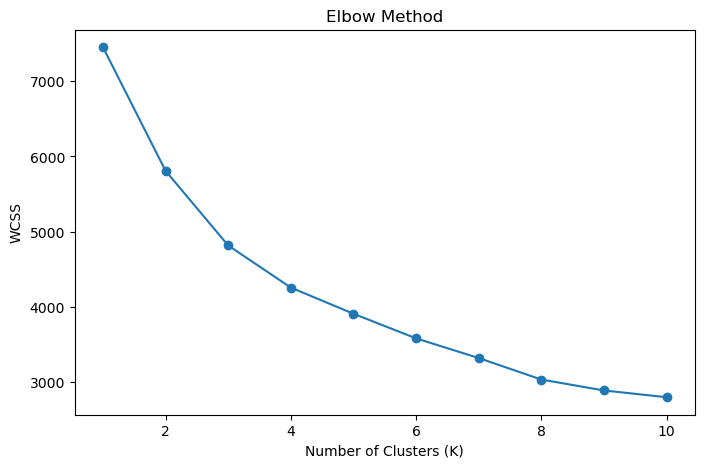

In [53]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [54]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    print(f"K = {k} --> Silhouette Score = {score:.4f}")

K = 2 --> Silhouette Score = 0.3039
K = 3 --> Silhouette Score = 0.3262
K = 4 --> Silhouette Score = 0.1927
K = 5 --> Silhouette Score = 0.2006
K = 6 --> Silhouette Score = 0.2071
K = 7 --> Silhouette Score = 0.2041
K = 8 --> Silhouette Score = 0.2084
K = 9 --> Silhouette Score = 0.2163
K = 10 --> Silhouette Score = 0.2091


In [55]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)


cluster_df["cluster"] = clusters

In [56]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["brand"]
)

brand,APPLE,ASUS,Avita,DELL,HP,Lenovo,MSI,acer
cluster,,,,,,,,
0,9,175,5,134,95,117,27,40
1,12,58,1,15,35,26,23,10
2,2,10,0,0,6,1,0,1


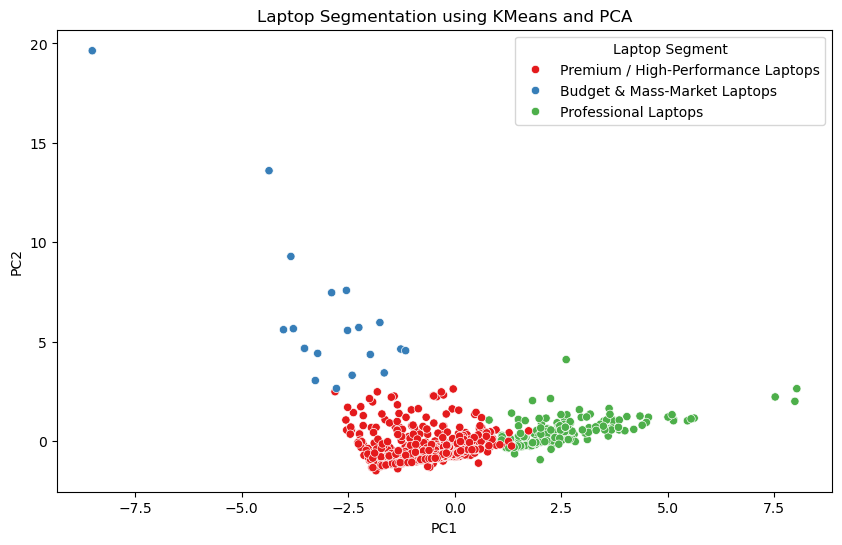

In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,6))



cluster_names = {
    0: "Premium / High-Performance Laptops",
    1: "Professional Laptops",
    2: "Budget & Mass-Market Laptops"
}

cluster_labels = pd.Series(clusters).map(cluster_names)


sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=cluster_labels,
    palette="Set1"
)




plt.xlabel("PC1")
plt.ylabel("PC2")


plt.legend(title="Laptop Segment")
plt.title("Laptop Segmentation using KMeans and PCA")
plt.show()

**Although the business initially expected four segments (Budget, Professional, Gaming, Premium), Silhouette Analysis indicated that the optimal number of clusters is 3 (score = 0.3278). Therefore, K-Means with K=3 was selected to obtain the most meaningful and well-separated customer segments.**



**From the above visualization we can say that Premium Laptops are the most dominate ones and the Budget-friendly laptops are very few. rofessional Laptops are present in a moderate quantity..**

**Now we will explore what type of information do each cluster holds and draw some insights based on it:**

In [58]:
cluster_profile = cluster_df.groupby("cluster").agg({
    "price":"mean",
    "ram_gb":"mean",
    "graphic_card_gb":"mean",
    "total_storage":"mean",
    "performance_score":"mean",
    "rating":"mean",
    "number of ratings":"mean",
    "number of reviews":"mean"
}).round(2)

cluster_profile

,price,ram_gb,graphic_card_gb,total_storage,performance_score,rating,number of ratings,number of reviews
cluster,,,,,,,,
0,63649.39,6.57,0.86,651.91,18.28,3.58,198.92,24.28
1,123263.53,15.96,2.43,795.73,40.77,3.51,81.94,11.42
2,47465.95,6.40,0.90,678.40,17.65,3.80,5298.70,613.50


In [59]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["brand"]
)

brand,APPLE,ASUS,Avita,DELL,HP,Lenovo,MSI,acer
cluster,,,,,,,,
0,9,175,5,134,95,117,27,40
1,12,58,1,15,35,26,23,10
2,2,10,0,0,6,1,0,1


In [60]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["os"]
)

os,DOS,Mac,Windows
cluster,,,
0,10,9,583
1,5,12,163
2,1,2,17


**CONCLUSION:** The K-Means algorithm clearly suggests that premium laptops are the most dominant segment, while budget-friendly laptops are comparatively fewer. Since the dataset contained multiple features, we analyzed the clusters using K-Means along with dimensionality reduction techniques such as PCA to visualize and understand the underlying patterns.